In [2]:
import pandas as pd
import numpy as np


Matplotlib is building the font cache; this may take a moment.


Normal RMS summary


,count,mean,std,min,25%,50%,75%,max
AI0_Vibration_RMS,19991.0,0.066292,0.024379,0.011442,0.047085,0.064594,0.083143,0.192372
AI1_Vibration_RMS,19991.0,0.104688,0.056333,0.014640,0.052656,0.094862,0.154095,0.237916
AI2_Current_RMS,19991.0,117.348845,35.720126,60.859365,86.074524,104.518346,150.009668,204.154049


IQR thresholds learned from normal data


,lower,upper
AI0_Vibration_RMS,-0.007003,0.137231
AI1_Vibration_RMS,-0.099503,0.306255
AI2_Current_RMS,-9.828193,245.912384


Outlier RMS rows: 331 / 600 (55.17%)


,TimeStamp,AI0_Vibration_RMS,AI1_Vibration_RMS,AI2_Current_RMS
9,51:17.2,0.485795,0.349914,88.056873
10,51:17.3,0.477927,0.311141,105.670828
11,51:17.4,0.346695,0.257149,110.103845
12,51:17.5,0.299265,0.263077,114.611546
13,51:17.6,0.430908,0.215982,111.643824
14,51:17.7,0.454039,0.206219,115.428836
15,51:17.8,0.444170,0.223286,114.762097
16,51:17.9,0.503249,0.289855,105.130169
17,51:18.0,0.595855,0.292099,94.178366
18,51:18.1,0.631943,0.289081,87.617620


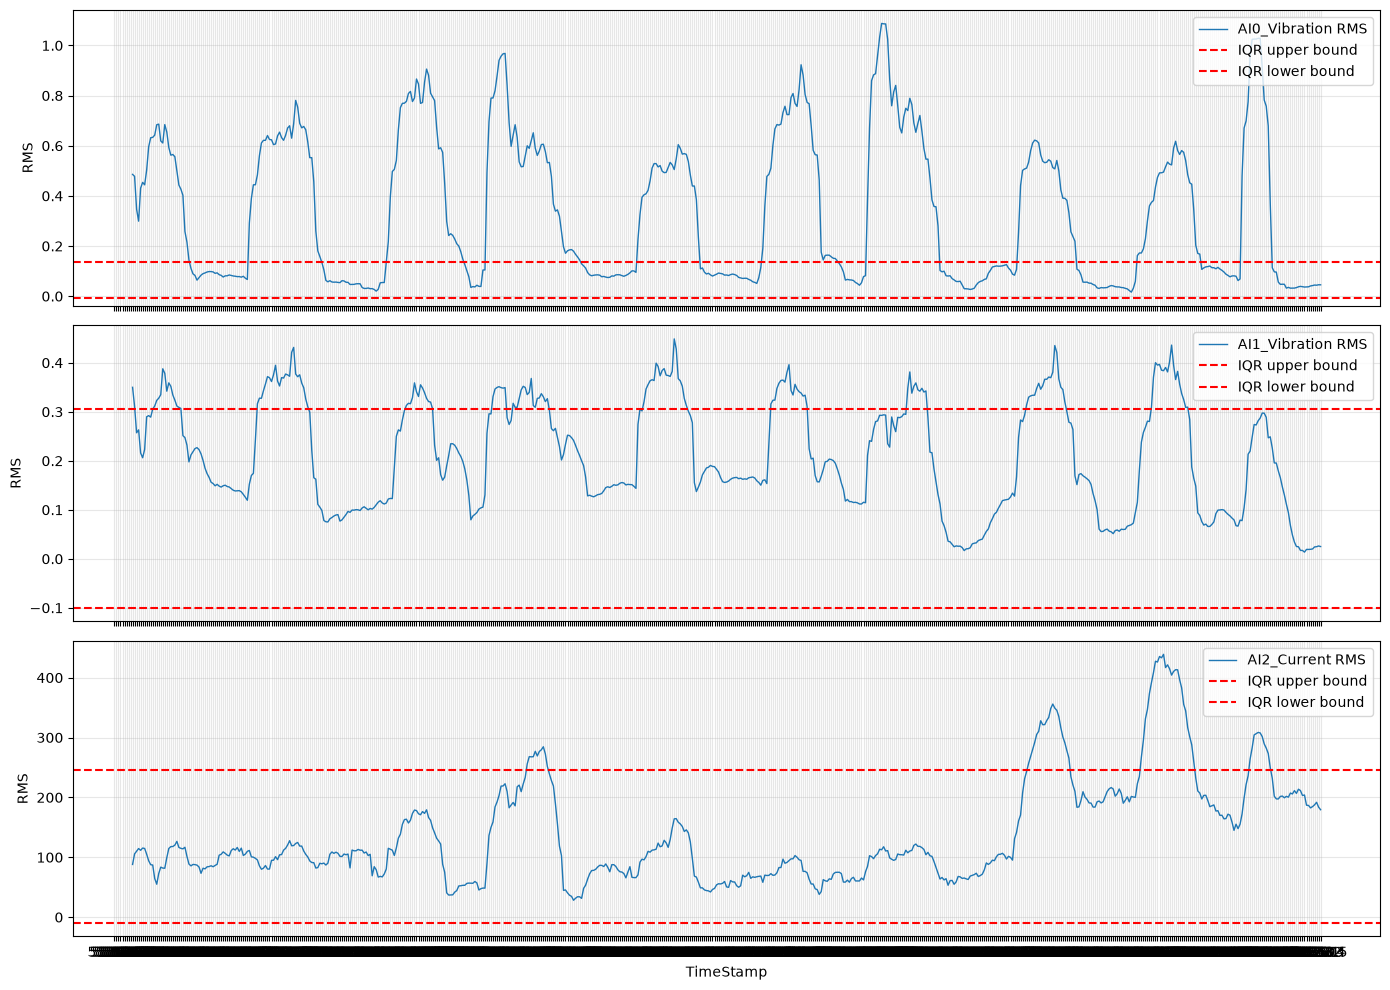

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



DATA_DIR = Path.cwd()
NORMAL_PATH = DATA_DIR / "press_data_normal.csv"
OUTLIER_PATH = DATA_DIR / "outlier_data.csv"
# 데이터 읽기

SIGNAL_COLUMNS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
# 사용할 센서 정의 

WINDOW_SAMPLES = 10  # 0.1-second sampling, so this is a 1-second RMS window
# 샘플 하나 크기 0.1초 가정

def load_press_data(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path, index_col=0)
    data["TimeStamp"] = data["TimeStamp"].astype(str)
    return data
# 데이터 읽기

def add_rolling_rms(data: pd.DataFrame, window: int = WINDOW_SAMPLES) -> pd.DataFrame:
    result = data.copy()
    for column in SIGNAL_COLUMNS:
        result[f"{column}_RMS"] = np.sqrt(
            result[column].pow(2).rolling(window=window, min_periods=window).mean()
        )
    return result
# RMS 계산

def iqr_bounds(normal_rms: pd.DataFrame) -> pd.DataFrame:
    bounds = {}
    for column in [f"{name}_RMS" for name in SIGNAL_COLUMNS]:
        q1 = normal_rms[column].quantile(0.25)
        q3 = normal_rms[column].quantile(0.75)
        iqr = q3 - q1
        bounds[column] = {
            "lower": q1 - 1.5 * iqr,
            "upper": q3 + 1.5 * iqr,
            "q1": q1,
            "q3": q3,
        }
    return pd.DataFrame(bounds).T
# 정상 데이터의 기준 만들기

normal = add_rolling_rms(load_press_data(NORMAL_PATH))
outlier = add_rolling_rms(load_press_data(OUTLIER_PATH))
rms_columns = [f"{name}_RMS" for name in SIGNAL_COLUMNS]
bounds = iqr_bounds(normal[rms_columns])

# Detect rows where at least one sensor's rolling RMS is outside the normal range.
outlier_flags = pd.DataFrame(index=outlier.index)
for column in rms_columns:
    outlier_flags[f"{column}_outlier"] = (
        (outlier[column] < bounds.loc[column, "lower"])
        | (outlier[column] > bounds.loc[column, "upper"])
    )
outlier["RMS_outlier"] = outlier_flags.any(axis=1)

print("Normal RMS summary")
display(normal[rms_columns].describe().T)
print("IQR thresholds learned from normal data")
display(bounds[["lower", "upper"]])
print(
    f"Outlier RMS rows: {outlier['RMS_outlier'].sum()} / {len(outlier)} "
    f"({outlier['RMS_outlier'].mean() * 100:.2f}%)"
)
display(outlier.loc[outlier["RMS_outlier"], ["TimeStamp", *rms_columns]].head(20))

fig, axes = plt.subplots(len(SIGNAL_COLUMNS), 1, figsize=(14, 10), sharex=True)
for axis, signal in zip(axes, SIGNAL_COLUMNS):
    rms_column = f"{signal}_RMS"
    axis.plot(outlier["TimeStamp"], outlier[rms_column], label=f"{signal} RMS", linewidth=1)
    axis.axhline(bounds.loc[rms_column, "upper"], color="red", linestyle="--", label="IQR upper bound")
    axis.axhline(bounds.loc[rms_column, "lower"], color="red", linestyle="--", label="IQR lower bound")
    axis.set_ylabel("RMS")
    axis.legend(loc="upper right")
    axis.grid(alpha=0.3)
axes[-1].set_xlabel("TimeStamp")
plt.tight_layout()
plt.show()
